# Etude de la stabilité des neurones des réseaux du benchmark

In [1]:
import pandas as pd
import numpy as np

tab = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/6x200-0.015/03_19_16h29_06s_histogramme_contraintes_relu_relaxees/stable_actives_study.csv")

In [2]:
tab.columns

Index(['Unnamed: 0', 'label', 'data_index', 'Number_actives_stable',
       'Number_inactives_stable', 'Number_targets', 'Stable_Actives_Layer_1',
       'Stable_Inactives_Layer_1', 'Stable_Actives_Layer_2',
       'Stable_Inactives_Layer_2', 'Stable_Actives_Layer_3',
       'Stable_Inactives_Layer_3', 'Stable_Actives_Layer_4',
       'Stable_Inactives_Layer_4', 'Stable_Actives_Layer_5',
       'Stable_Inactives_Layer_5', 'Stable_Actives_Layer_6',
       'Stable_Inactives_Layer_6', 'Stable_Actives_Layer_7',
       'Stable_Inactives_Layer_7'],
      dtype='object')

In [8]:
tab['Stable_Actives_Layer_1']

0     41.0
1     37.0
2     36.0
3     39.0
4     39.0
      ... 
95    38.0
96    42.0
97    35.0
98    39.0
99    36.0
Name: Stable_Actives_Layer_1, Length: 100, dtype: float64

In [3]:
K = 7
n = [784, 200, 200, 200, 200, 200, 200, 10]  # Nombre de neurones par couche (entrée, cachées, sortie)

In [4]:
actives = []
inactives = []
actives_percentage = []
inactives_percentage = []
for k in range(1, K + 1):
    nb_stable_actives_layer_k = tab[f'Stable_Actives_Layer_{k}'].mean()
    nb_stable_inactives_layer_k = tab[f'Stable_Inactives_Layer_{k}'].mean()
    print(
        f"STUDY : Layer {k} - Stable actives neurons: {nb_stable_actives_layer_k} - Stable inactives neurons: {nb_stable_inactives_layer_k}"
    )
    actives.append(nb_stable_actives_layer_k)
    inactives.append(nb_stable_inactives_layer_k)
    actives_percentage.append(nb_stable_actives_layer_k / n[k] * 100)
    inactives_percentage.append(nb_stable_inactives_layer_k / n[k] * 100)

STUDY : Layer 1 - Stable actives neurons: 38.57 - Stable inactives neurons: 148.83
STUDY : Layer 2 - Stable actives neurons: 81.13 - Stable inactives neurons: 88.94
STUDY : Layer 3 - Stable actives neurons: 51.36 - Stable inactives neurons: 123.72
STUDY : Layer 4 - Stable actives neurons: 40.99 - Stable inactives neurons: 126.86
STUDY : Layer 5 - Stable actives neurons: 34.66 - Stable inactives neurons: 117.66
STUDY : Layer 6 - Stable actives neurons: 0.0 - Stable inactives neurons: 106.56
STUDY : Layer 7 - Stable actives neurons: 0.0 - Stable inactives neurons: 0.0


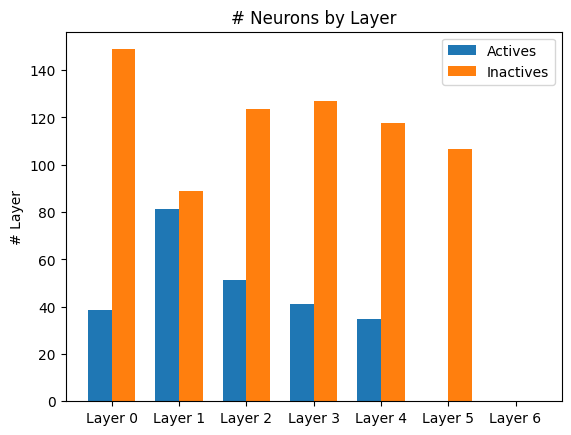

In [5]:
actives = np.array(actives)
inactives = np.array(inactives)

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, K + 1)

# Largeur des barres
width = 0.35

plt.figure()

plt.bar(x - width/2, actives, width, label='Actives')
plt.bar(x + width/2, inactives, width, label='Inactives')

# Labels
plt.ylabel("# Layer")
plt.title("# Neurons by Layer")

# Numéros des couches sur l'axe x
plt.xticks(x, [f"Layer {i}" for i in range(K)])

plt.legend()

plt.show()

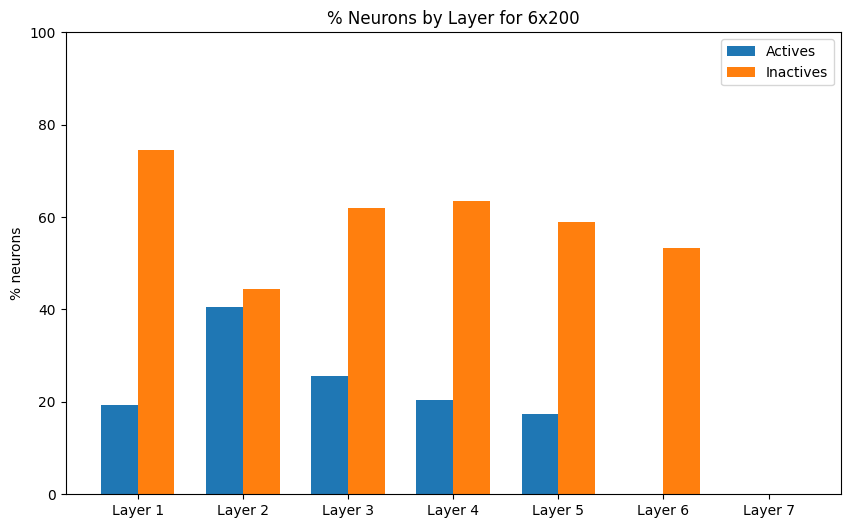

In [10]:

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, K + 1)

# Largeur des barres
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, actives_percentage, width, label='Actives')
plt.bar(x + width/2, inactives_percentage, width, label='Inactives')

# Labels
plt.ylabel("% neurons")
plt.title("% Neurons by Layer for 6x200")

# Numéros des couches sur l'axe x
plt.xticks(x, [f"Layer {i}" for i in range(1, K + 1)])

plt.legend()
plt.ylim(0, 100)

plt.show()